
# Step 1: Data loading and initial Exploration

- Load all datasets using Pandas  
- Inspect structure using .head(), .info(), .describe() 
- Identify primary and foreign keys 
- Understand relationships between tables

In [2]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

#Function to validate or confirm the primary key or composite key of the DataFrame.
def validatePrimaryKeyInDataset(dataframe, column):
    if type(column) is str:
        #primaryKey check
        if (dataframe[column].is_unique and dataframe[column].notna().all()):
            return True
    elif type(column) is list:
        #compositeKey check
        if not dataframe[column].duplicated().any():
            return True
    return False

#Function to validate or confirm the foreign key of the DataFrame.
def validateForignKeyInDataset(primaryDataFrame, primaryKey, forignDataFrame, forignKey):
    if(forignDataFrame[forignKey].isin(primaryDataFrame[primaryKey]).all()):
        return True
    return False


df_customers = pd.read_csv("..\python_project_aiml_logicmojo_dataset\customers.csv")
df_orders = pd.read_csv("..\python_project_aiml_logicmojo_dataset\orders.csv")
df_order_items = pd.read_csv("..\python_project_aiml_logicmojo_dataset\order_item.csv")
df_payments = pd.read_csv("..\python_project_aiml_logicmojo_dataset\payments.csv")
df_reviews = pd.read_csv(r"..\python_project_aiml_logicmojo_dataset\reviews.csv")
df_products = pd.read_csv("..\python_project_aiml_logicmojo_dataset\products.csv")
df_sellers = pd.read_csv("..\python_project_aiml_logicmojo_dataset\sellers.csv")
df_geolocation = pd.read_csv("..\python_project_aiml_logicmojo_dataset\location.csv")
df_category_translation = pd.read_csv("..\python_project_aiml_logicmojo_dataset\category_translation.csv")

## Customers

In [3]:
display(df_customers.head(4))
display(df_customers.info())
display(df_customers.describe())

print("*** Key points ***")
print("The customer table has no null values in any column.")
if(validatePrimaryKeyInDataset(df_customers, "customer_unique_id")):
    print("Primary key: customer_unique_id")
if(validatePrimaryKeyInDataset(df_customers, "customer_id")):
    print("Primary key: customer_id")

print("The customer_id column is different from the customer_unique_id column.")
df_customers.loc[df_customers["customer_id"].isin(df_customers["customer_unique_id"])]



,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


*** Key points ***
The customer table has no null values in any column.
Primary key: customer_id
The customer_id column is different from the customer_unique_id column.


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


## Orders

In [4]:
display(df_orders.head(4))
display(df_orders.info())
display(df_orders.describe())

print("*** Key points ***")
print("The orders table has null values in 'order_approved_at', 'order_delivered_carrier_date' & 'order_delivered_customer_date' columns.")
if(validatePrimaryKeyInDataset(df_orders, "order_id")):
    print("Primary key: order_id")

if(validateForignKeyInDataset(df_customers, "customer_id", df_orders, "customer_id")):
    print("Foreign key: customer_id (Customers)")

print("The order status can take the following values:")
df_orders["order_status"].unique().tolist()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


*** Key points ***
The orders table has null values in 'order_approved_at', 'order_delivered_carrier_date' & 'order_delivered_customer_date' columns.
Primary key: order_id
Foreign key: customer_id (Customers)
The order status can take the following values:


['delivered',
 'invoiced',
 'shipped',
 'processing',
 'unavailable',
 'canceled',
 'created',
 'approved']

## Order Item

In [5]:
display(df_order_items.head())
display(df_order_items.info())
display(df_order_items.describe())

print("*** Key points ***")
print("The order_item table has no null values in any column.")
if(validatePrimaryKeyInDataset(df_order_items, "order_id")):
    print("Primary key: order_id")
    
if(validatePrimaryKeyInDataset(df_order_items, ["order_id", "order_item_id"])):
    print("Composite key: order_id, order_item_id")

if(validateForignKeyInDataset(df_products, "product_id", df_order_items, "product_id")):
    print("Foreign key: product_id (Products)")

if(validateForignKeyInDataset(df_orders, "order_id", df_order_items, "order_id")):
    print("Foreign key: order_id (Orders)")

if(validateForignKeyInDataset(df_sellers, "seller_id", df_order_items, "seller_id")):
    print("Foreign key: seller_id (Sellers)")

print("There are orders where freight values are zero.")
print("The maximum observed order size is 21 items.")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


None

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


*** Key points ***
The order_item table has no null values in any column.
Composite key: order_id, order_item_id
Foreign key: product_id (Products)
Foreign key: order_id (Orders)
Foreign key: seller_id (Sellers)
There are orders where freight values are zero.
The maximum observed order size is 21 items.


## Payments

In [6]:
display(df_payments.head())
display(df_payments.info())
display(df_payments.describe())

print("*** Key points ***")
print("The payments table has no null values in any column.")
if(validatePrimaryKeyInDataset(df_payments, "order_id")):
    print("Primary key: order_id")
    
if(validatePrimaryKeyInDataset(df_payments, ["order_id", "payment_sequential"])):
    print("Composite key: order_id, payment_sequential")


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


None

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


*** Key points ***
The payments table has no null values in any column.
Composite key: order_id, payment_sequential


## Reviews

In [7]:
display(df_reviews.head())
display(df_reviews.info())
display(df_reviews.describe())

print("*** Key points ***")
print("The review table has null values in 'review_comment_title', 'review_comment_message' columns.")
if(validatePrimaryKeyInDataset(df_reviews, "review_id")):
    print("Primary key: review_id")

if(validatePrimaryKeyInDataset(df_reviews, ["review_id", "order_id"])):
    print("Composite key: review_id, order_id")

if(validateForignKeyInDataset(df_orders, "order_id", df_reviews, "order_id")):
    print("Foreign key: order_id (Orders)")


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


None

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


*** Key points ***
The review table has null values in 'review_comment_title', 'review_comment_message' columns.
Composite key: review_id, order_id
Foreign key: order_id (Orders)


## Products

In [8]:
display(df_products.head())
display(df_products.info())
display(df_products.describe())

print("*** Key points ***")
print("The product table has null values in multiple columns.")
if(validatePrimaryKeyInDataset(df_products, "product_id")):
    print("Primary key: product_id")

print("Not all category translation we have")
# Not all category translation we have
merged = pd.merge(
    df_products[~df_products["product_category_name"].isna()],
    df_category_translation,
    on="product_category_name",
    how="left"
)

merged.loc[merged["product_category_name_english"].isna(), "product_category_name"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


*** Key points ***
The product table has null values in multiple columns.
Primary key: product_id
Not all category translation we have


1581                                          pc_gamer
5703     portateis_cozinha_e_preparadores_de_alimentos
7176     portateis_cozinha_e_preparadores_de_alimentos
7326                                          pc_gamer
8648     portateis_cozinha_e_preparadores_de_alimentos
10823    portateis_cozinha_e_preparadores_de_alimentos
13996    portateis_cozinha_e_preparadores_de_alimentos
15875    portateis_cozinha_e_preparadores_de_alimentos
16609                                         pc_gamer
17460    portateis_cozinha_e_preparadores_de_alimentos
18252    portateis_cozinha_e_preparadores_de_alimentos
26398    portateis_cozinha_e_preparadores_de_alimentos
29370    portateis_cozinha_e_preparadores_de_alimentos
Name: product_category_name, dtype: object

## Sellers

In [9]:
display(df_sellers.head())
display(df_sellers.info())
display(df_sellers.describe())

print("*** Key points ***")
print("The seller table has no null values in any column.")
if(validatePrimaryKeyInDataset(df_sellers, "seller_id")):
    print("Primary key: seller_id")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


None

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


*** Key points ***
The seller table has no null values in any column.
Primary key: seller_id


## Location

In [10]:
display(df_geolocation.head())
display(df_geolocation.info())
display(df_geolocation.describe())

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


None

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


## Category translation

In [11]:
display(df_category_translation.head())
display(df_category_translation.info())
display(df_category_translation.describe())

if(validatePrimaryKeyInDataset(df_category_translation, "product_category_name")):
    print("Primary key: product_category_name")

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


Primary key: product_category_name


# Step 2: Data Cleaning and Preprocessing

* Handle missing values appropriately
* Remove duplicate records
* Convert date columns to datetime format
* Validate data types and ranges
* Standardize column names if required 


## Customers

In [12]:
display(df_customers.isna().any())
print("No missing values.\n")

display(df_customers.duplicated().any())
print("No duplicate records found.\n")

df_customers["customer_id"] = df_customers["customer_id"].astype("string")
df_customers["customer_unique_id"] = df_customers["customer_unique_id"].astype("string")
df_customers["customer_city"] = df_customers["customer_city"].astype("string")
df_customers["customer_state"] = df_customers["customer_state"].astype("string")
display(df_customers.info())


customer_id                 False
customer_unique_id          False
customer_zip_code_prefix    False
customer_city               False
customer_state              False
dtype: bool

No missing values.



np.False_

No duplicate records found.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  string
 1   customer_unique_id        99441 non-null  string
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  string
 4   customer_state            99441 non-null  string
dtypes: int64(1), string(4)
memory usage: 3.8 MB


None

## Orders

In [13]:
#Handle missing values appropriately
display(df_orders.isna().any())
print("Missing values columns: order_approved_at, order_delivered_carrier_date, order_delivered_customer_date \n")

#Convert date columns to datetime format
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"])
df_orders["order_approved_at"] = pd.to_datetime(df_orders["order_approved_at"])
df_orders["order_delivered_carrier_date"] = pd.to_datetime(df_orders["order_delivered_carrier_date"])
df_orders["order_delivered_customer_date"] = pd.to_datetime(df_orders["order_delivered_customer_date"])
df_orders["order_estimated_delivery_date"] = pd.to_datetime(df_orders["order_estimated_delivery_date"])
df_orders["order_id"] = df_orders["order_id"].astype("string")
df_orders["customer_id"] = df_orders["customer_id"].astype("string")
df_orders["order_status"] = df_orders["order_status"].astype("string")

delivered_status_mask = (df_orders["order_status"] == "delivered")
non_delivered_status_mask = (df_orders["order_status"] != "delivered")
na_mask = (
        df_orders["order_approved_at"].isna() |
        df_orders["order_delivered_carrier_date"].isna() |
        df_orders["order_delivered_customer_date"].isna()
    )

print("Total number of delivered records: ", len(df_orders[delivered_status_mask]))
print("Number of records having missing values in delivered status records: ", len(df_orders[delivered_status_mask & na_mask]))
print("Since it's only 23 rows out of 96478, safest option is to drop them.")
# Drop inconsistent delivered orders
df_orders = df_orders[~(delivered_status_mask & na_mask)]

print("Total number of non delivered records: ", len(df_orders[non_delivered_status_mask]))
print("Number of records having missing values in non delivered status records: ", len(df_orders[non_delivered_status_mask & na_mask]))
print("Here, nulls are expected: if an order was canceled or not delivered, it won’t have dates.Is better to move that data in order data frame.")
# Keep other statuses as-is
df_non_delivered = df_orders[df_orders["order_status"]!="delivered"]

# Drop non delivered orders from main datasets
df_orders = df_orders[~(non_delivered_status_mask)]

display(df_orders.info())


order_id                         False
customer_id                      False
order_status                     False
order_purchase_timestamp         False
order_approved_at                 True
order_delivered_carrier_date      True
order_delivered_customer_date     True
order_estimated_delivery_date    False
dtype: bool

Missing values columns: order_approved_at, order_delivered_carrier_date, order_delivered_customer_date 

Total number of delivered records:  96478
Number of records having missing values in delivered status records:  23
Since it's only 23 rows out of 96478, safest option is to drop them.
Total number of non delivered records:  2963
Number of records having missing values in non delivered status records:  2957
Here, nulls are expected: if an order was canceled or not delivered, it won’t have dates.Is better to move that data in order data frame.
<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  string        
 1   customer_id                    96455 non-null  string        
 2   order_status                   96455 non-null  string        
 3   order_

C:\Users\amans\AppData\Local\Temp\ipykernel_9444\2146761802.py:29: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("Total number of non delivered records: ", len(df_orders[non_delivered_status_mask]))
C:\Users\amans\AppData\Local\Temp\ipykernel_9444\2146761802.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("Number of records having missing values in non delivered status records: ", len(df_orders[non_delivered_status_mask & na_mask]))
C:\Users\amans\AppData\Local\Temp\ipykernel_9444\2146761802.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_orders = df_orders[~(non_delivered_status_mask)]


None

## Order Item

In [14]:
#Handle missing values appropriately
display(df_order_items.isna().any())
print("No missing values found\n")

display(df_order_items.duplicated().any())
print("No duplicate records\n")

df_order_items["shipping_limit_date"] = pd.to_datetime(df_order_items["shipping_limit_date"])
df_order_items["order_id"] = df_order_items["order_id"].astype("string")
df_order_items["order_item_id"] =df_order_items["order_item_id"].astype("int")
df_order_items["product_id"] = df_order_items["product_id"].astype("string")
df_order_items["seller_id"] = df_order_items["seller_id"].astype("string")
display(df_order_items.info())


order_id               False
order_item_id          False
product_id             False
seller_id              False
shipping_limit_date    False
price                  False
freight_value          False
dtype: bool

No missing values found



np.False_

No duplicate records

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  string        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  string        
 3   seller_id            112650 non-null  string        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), string(3)
memory usage: 6.0 MB


None

## Payments

In [15]:
#Handle missing values appropriately
display(df_payments.isna().any())
print("No missing values found\n")

display(df_payments.duplicated().any())
print("No duplicate records\n")

df_payments["order_id"] = df_payments["order_id"].astype("string")
df_payments["payment_type"] = df_payments["payment_type"].astype("string")
display(df_payments.info())

df_payments["payment_type"].unique() 






order_id                False
payment_sequential      False
payment_type            False
payment_installments    False
payment_value           False
dtype: bool

No missing values found



np.False_

No duplicate records

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  string 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  string 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), string(2)
memory usage: 4.0 MB


None

<StringArray>
['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']
Length: 5, dtype: string

## Reviews

In [16]:
#Handle missing values appropriately
display(df_reviews.isna().any())
df_reviews["review_comment_title"] = df_reviews["review_comment_title"].fillna("Not Found")
df_reviews["review_comment_message"] = df_reviews["review_comment_message"].fillna("Not Found")
display(df_reviews.isna().any())

display(df_reviews.duplicated().any())
print("No duplicate records\n")

df_reviews["review_id"] = df_reviews["review_id"].astype("string")
df_reviews["order_id"] =df_reviews["order_id"].astype("string")
df_reviews["review_comment_title"] = df_reviews["review_comment_title"].astype("string")
df_reviews["review_comment_message"] = df_reviews["review_comment_message"].astype("string")
df_reviews["review_creation_date"] = pd.to_datetime(df_reviews["review_creation_date"])
df_reviews["review_answer_timestamp"] = pd.to_datetime(df_reviews["review_answer_timestamp"])

df_reviews.info()



review_id                  False
order_id                   False
review_score               False
review_comment_title        True
review_comment_message      True
review_creation_date       False
review_answer_timestamp    False
dtype: bool

review_id                  False
order_id                   False
review_score               False
review_comment_title       False
review_comment_message     False
review_creation_date       False
review_answer_timestamp    False
dtype: bool

np.False_

No duplicate records

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  string        
 1   order_id                 99224 non-null  string        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  string        
 4   review_comment_message   99224 non-null  string        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), string(4)
memory usage: 5.3 MB


# Step 3: Data Integration (Critical Component)

You must construct a Master Dataset by merging multiple tables.
Recommended sequence:
1. orders + customers 
2. orders + order_items 
3. order_items + products 
4. orders + payments 
5. orders + reviews 
6. order_items + sellers 
7. products + category_translation
    
Final output:
A single consolidated dataset representing a unified business view


## 1. Orders + Customers 

In [17]:
# Perform Left Join
result = pd.merge(df_orders, df_customers, on='customer_id', how='left')
result.head(5)
df_orders.info()
df_customers.info()
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96455 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  string        
 1   customer_id                    96455 non-null  string        
 2   order_status                   96455 non-null  string        
 3   order_purchase_timestamp       96455 non-null  datetime64[ns]
 4   order_approved_at              96455 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96455 non-null  datetime64[ns]
 6   order_delivered_customer_date  96455 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96455 non-null  datetime64[ns]
dtypes: datetime64[ns](5), string(3)
memory usage: 6.6 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  --

## 2. Orders + Order_items 

In [18]:
# Perform Left Join
result = pd.merge(result, df_order_items, on='order_id', how='left')
result.head(5)
result.info() # Not all order item id record are avaiable agaist every order.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110173 entries, 0 to 110172
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110173 non-null  string        
 1   customer_id                    110173 non-null  string        
 2   order_status                   110173 non-null  string        
 3   order_purchase_timestamp       110173 non-null  datetime64[ns]
 4   order_approved_at              110173 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110173 non-null  datetime64[ns]
 6   order_delivered_customer_date  110173 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110173 non-null  datetime64[ns]
 8   customer_unique_id             110173 non-null  string        
 9   customer_zip_code_prefix       110173 non-null  int64         
 10  customer_city                  110173 non-null  string        
 11  

## 3. Order_items + Products 

In [19]:
# Perform Left Join
result = pd.merge(result, df_products, on='product_id', how='left')
result.head(5)
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110173 entries, 0 to 110172
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110173 non-null  string        
 1   customer_id                    110173 non-null  string        
 2   order_status                   110173 non-null  string        
 3   order_purchase_timestamp       110173 non-null  datetime64[ns]
 4   order_approved_at              110173 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110173 non-null  datetime64[ns]
 6   order_delivered_customer_date  110173 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110173 non-null  datetime64[ns]
 8   customer_unique_id             110173 non-null  string        
 9   customer_zip_code_prefix       110173 non-null  int64         
 10  customer_city                  110173 non-null  string        
 11  

## 4. Orders + Payments 

In [20]:
# Perform Left Join
result = pd.merge(result, df_payments, on='order_id', how='left')
result.head(5)
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115014 entries, 0 to 115013
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115014 non-null  string        
 1   customer_id                    115014 non-null  string        
 2   order_status                   115014 non-null  string        
 3   order_purchase_timestamp       115014 non-null  datetime64[ns]
 4   order_approved_at              115014 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115014 non-null  datetime64[ns]
 6   order_delivered_customer_date  115014 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115014 non-null  datetime64[ns]
 8   customer_unique_id             115014 non-null  string        
 9   customer_zip_code_prefix       115014 non-null  int64         
 10  customer_city                  115014 non-null  string        
 11  

## 5. Orders + Reviews 

In [21]:
# Perform Left Join
result = pd.merge(result, df_reviews, on='order_id', how='left')
result.head(5)
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115699 entries, 0 to 115698
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115699 non-null  string        
 1   customer_id                    115699 non-null  string        
 2   order_status                   115699 non-null  string        
 3   order_purchase_timestamp       115699 non-null  datetime64[ns]
 4   order_approved_at              115699 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115699 non-null  datetime64[ns]
 6   order_delivered_customer_date  115699 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115699 non-null  datetime64[ns]
 8   customer_unique_id             115699 non-null  string        
 9   customer_zip_code_prefix       115699 non-null  int64         
 10  customer_city                  115699 non-null  string        
 11  

## 6. order_items + sellers 

In [22]:
# Perform Left Join
result = pd.merge(result, df_sellers, on='seller_id', how='left')
result.head(5)
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115699 entries, 0 to 115698
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115699 non-null  string        
 1   customer_id                    115699 non-null  string        
 2   order_status                   115699 non-null  string        
 3   order_purchase_timestamp       115699 non-null  datetime64[ns]
 4   order_approved_at              115699 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115699 non-null  datetime64[ns]
 6   order_delivered_customer_date  115699 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115699 non-null  datetime64[ns]
 8   customer_unique_id             115699 non-null  string        
 9   customer_zip_code_prefix       115699 non-null  int64         
 10  customer_city                  115699 non-null  string        
 11  

## 7. products + category_translation 

In [23]:
# Perform Left Join
result = pd.merge(result, df_category_translation, on='product_category_name', how='left')
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115699 entries, 0 to 115698
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115699 non-null  string        
 1   customer_id                    115699 non-null  string        
 2   order_status                   115699 non-null  string        
 3   order_purchase_timestamp       115699 non-null  datetime64[ns]
 4   order_approved_at              115699 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115699 non-null  datetime64[ns]
 6   order_delivered_customer_date  115699 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115699 non-null  datetime64[ns]
 8   customer_unique_id             115699 non-null  string        
 9   customer_zip_code_prefix       115699 non-null  int64         
 10  customer_city                  115699 non-null  string        
 11  

In [24]:
pd.set_option('display.max_columns', None)
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto


# Step 4: Feature Engineering
Create meaningful features such as:
* Total order value (aggregated from order_items or payments) 
* Delivery time (order purchase to delivery date) 
* Number of items per order 
* Customer purchase frequency 
* Customer lifetime value (basic approximation) 
* Average order value per customer 


## Total order value (aggregated from order_items or payments)

In [25]:
# Compute unique payment totals per order
unique_totals = (
    result[["order_id", "payment_sequential","payment_value"]].drop_duplicates(subset=["order_id", "payment_sequential"])   # only unique payments per order
      .groupby("order_id")["payment_value"].sum()
)
result["total_order_value"] = result["order_id"].map(unique_totals)
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto,179.12


## Delivery time (order purchase to delivery date)

In [26]:
result["delivery_time"] = result["order_delivered_customer_date"] - result["order_purchase_timestamp"]
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,total_order_value,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery,141.46,13 days 18:46:08
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto,179.12,9 days 09:27:40


## Number of items per order

In [27]:
unique_items = (
    result[["order_id", "order_item_id"]].drop_duplicates(subset=["order_id", "order_item_id"])   # only unique payments per order
      .groupby("order_id")["order_item_id"].count()
)

result["number_of_items_per_order"] = result["order_id"].map(unique_items)
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,total_order_value,delivery_time,number_of_items_per_order
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery,141.46,13 days 18:46:08,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto,179.12,9 days 09:27:40,1


## Customer purchase frequency

In [28]:
order_per_customer = (
    result[["order_id", "customer_unique_id"]].drop_duplicates(subset=["order_id", "customer_unique_id"])
        .groupby("customer_unique_id")["order_id"].count()
)
result["customer_purchase_frequency"] = result["customer_unique_id"].map(order_per_customer)
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,total_order_value,delivery_time,number_of_items_per_order,customer_purchase_frequency
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery,141.46,13 days 18:46:08,1,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto,179.12,9 days 09:27:40,1,1


## Customer lifetime value (basic approximation)

In [29]:
customer_order_value = (
    result[["customer_unique_id", "order_id", "total_order_value"]].drop_duplicates(subset=["customer_unique_id", "order_id"])
    .groupby("customer_unique_id")["total_order_value"].sum()
)

result["customer_lifetime_value"] = result["customer_unique_id"].map(customer_order_value)
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,total_order_value,delivery_time,number_of_items_per_order,customer_purchase_frequency,customer_lifetime_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2,82.82
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2,82.82
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2,82.82
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery,141.46,13 days 18:46:08,1,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto,179.12,9 days 09:27:40,1,1,179.12


## Average order value per customer

In [30]:
result["average_order_value_per_customer"] = result["customer_lifetime_value"]/result["customer_purchase_frequency"]
result.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,total_order_value,delivery_time,number_of_items_per_order,customer_purchase_frequency,customer_lifetime_value,average_order_value_per_customer
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2,82.82,41.41
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2,82.82,41.41
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Not Found,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350,maua,SP,housewares,38.71,8 days 10:28:40,1,2,82.82,41.41
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP,perfumery,141.46,13 days 18:46:08,1,1,141.46,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,Not Found,Not Found,2018-08-18,2018-08-22 19:07:58,14840,guariba,SP,auto,179.12,9 days 09:27:40,1,1,179.12,179.12


# Step 5: Exploratory Data Analysis (EDA)

## Customer Analysis
* New vs repeat customers 
* High-value vs low-value customers 
* Geographic distribution of customers 


In [31]:
# New vs repeat customers

new_customers_data = result.loc[result["customer_purchase_frequency"] == 1]
repeat_customers_data = result.loc[result["customer_purchase_frequency"] > 1]

print("Count of new customers = ", len(new_customers_data["customer_unique_id"].unique()))
print("Count of repeat customers = ", len(repeat_customers_data["customer_unique_id"].unique()))

revenue_from_new_customers = (
    new_customers_data.drop_duplicates(subset=["customer_unique_id", "customer_lifetime_value"])["customer_lifetime_value"].sum()
)
print("Revenue from new customers =", revenue_from_new_customers)

revenue_from_repeat_customers = (
    repeat_customers_data.drop_duplicates(subset=["customer_unique_id", "customer_lifetime_value"])["customer_lifetime_value"].sum()
)
print("Revenue from repeat customers =", round(revenue_from_repeat_customers,2))


# High value vs low-value customers
value_of_customers = result[["customer_unique_id", "customer_lifetime_value"]].drop_duplicates()
high_value_customers_spends_threshold = value_of_customers["customer_lifetime_value"].quantile(0.75)
low_value_customers_spends_threshold = value_of_customers["customer_lifetime_value"].quantile(0.25)
print("High value customers spends threshold", high_value_customers_spends_threshold)
print("Low value customers spends threshold", low_value_customers_spends_threshold)

print("High value customers:\n")
display(value_of_customers.loc[value_of_customers["customer_lifetime_value"] > high_value_customers_spends_threshold])

print("Low value customers:\n")
display(value_of_customers.loc[value_of_customers["customer_lifetime_value"] < low_value_customers_spends_threshold])


# Geographic distribution of customers
geographic_distribution = result[["customer_unique_id", "customer_state", "customer_lifetime_value"]].drop_duplicates()
geographic_distribution_state_level = geographic_distribution.groupby(["customer_state"])["customer_lifetime_value"].sum()
display(geographic_distribution_state_level.sort_values())

geographic_distribution_of_customers = geographic_distribution.groupby("customer_state")["customer_unique_id"].count()
display(geographic_distribution_of_customers.sort_values())

Count of new customers =  90536
Count of repeat customers =  2800
Revenue from new customers = 14554876.59
Revenue from repeat customers = 864057.68
High value customers spends threshold 182.5425
Low value customers spends threshold 63.05
High value customers:



,customer_unique_id,customer_lifetime_value
12,f2a85dec752b8517b5e58a06ff3cd937,259.06
18,ccafc1c3f270410521c3c6f3b249870f,207.51
19,6e26bbeaa107ec34112c64e1ee31c0f5,1441.62
28,451e48381edab7f1f6dbfa6d728616ff,187.57
31,576ea0cab426cd8a00fad9a9c90a4494,227.68
...,...,...
115679,7bb6ca43f478742340256d516d9d86e3,194.91
115690,e03dbdf5e56c96b106d8115ac336f47f,389.43
115694,da62f9e57a76d978d02ab5362c509660,195.00
115695,737520a9aad80b3fbbdad19b66b37b30,271.01


Low value customers:



,customer_unique_id,customer_lifetime_value
6,72632f0f9dd73dfee390c9b22eb56dd6,28.62
9,39382392765b6dc74812866ee5ee92a7,35.95
15,e97109680b052ee858d93a539597bba7,50.13
16,e2dfa3127fedbbca9707b36304996dab,32.70
17,04cf8185c71090d28baa4407b2e6d600,54.36
...,...,...
115660,a3adfb1ef257529c6abe81be7726a63f,43.87
115663,6ca7990c03b703e57401911433372d1e,49.59
115674,bd7df6ff9e4a04991eea842883f79e9a,43.00
115676,a3983b8b6b679c9f645e6ef9517ac98d,48.75


customer_state
RR       9039.52
AP      16141.81
AC      19586.25
AM      27596.18
RO      57132.98
TO      60007.37
SE      70696.88
AL      94195.79
RN     100728.30
PI     105272.17
MS     134461.79
PB     138236.79
MA     148162.07
MT     181757.65
PA     212027.55
CE     266621.70
PE     309931.74
ES     317826.85
GO     335587.04
DF     346493.46
BA     591580.20
SC     595954.76
PR     782440.80
RS     861304.42
MG    1819846.71
RJ    2056021.98
SP    5772329.13
Name: customer_lifetime_value, dtype: float64

customer_state
RR       40
AP       66
AC       76
AM      140
RO      231
TO      267
SE      329
AL      387
PI      464
RN      464
PB      504
MS      681
MA      699
MT      856
PA      922
CE     1257
PE     1551
GO     1895
ES     1928
DF     2019
BA     3158
SC     3449
PR     4769
RS     5165
MG    10998
RJ    11915
SP    39144
Name: customer_unique_id, dtype: int64

## Revenue and Order Analysis
* Monthly revenue trends 
* Order volume trends 
* Peak sales periods 


In [32]:
order_analysis = result[["order_id", "order_purchase_timestamp", "total_order_value"]].drop_duplicates()
order_analysis["order_month"] = order_analysis["order_purchase_timestamp"].dt.to_period("M")

# Monthly revenue
monthly_revenue = order_analysis.groupby("order_month")["total_order_value"].sum()
display(monthly_revenue)

# Monthly order volume
monthly_orders = order_analysis.groupby("order_month")["order_id"].nunique()
display(monthly_orders)

# Peak sales (daily)
daily_sales = order_analysis.groupby(order_analysis["order_purchase_timestamp"].dt.date)["total_order_value"].sum()
peak_days = daily_sales.sort_values(ascending=False).head(5)
display(peak_days)

order_month
2016-09          0.00
2016-10      46566.71
2016-12         19.62
2017-01     127430.74
2017-02     269458.98
2017-03     414369.39
2017-04     390952.18
2017-05     566872.73
2017-06     490225.60
2017-07     566403.93
2017-08     646000.61
2017-09     700976.01
2017-10     751140.27
2017-11    1153393.22
2017-12     843199.17
2018-01    1078606.86
2018-02     966510.88
2018-03    1120678.00
2018-04    1132933.95
2018-05    1128836.69
2018-06    1011561.35
2018-07    1027383.10
2018-08     985414.28
Freq: M, Name: total_order_value, dtype: float64

order_month
2016-09       1
2016-10     265
2016-12       1
2017-01     748
2017-02    1641
2017-03    2546
2017-04    2303
2017-05    3545
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4149
2017-10    4478
2017-11    7288
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6096
2018-07    6156
2018-08    6351
Freq: M, Name: order_id, dtype: int64

order_purchase_timestamp
2017-11-24    175250.94
2017-11-25     70684.27
2018-05-16     63960.93
2018-08-06     62728.23
2018-05-07     60805.33
Name: total_order_value, dtype: float64

## Product Analysis
* Top-selling product categories 
* Revenue contribution by category 
* Product demand distribution 


In [33]:
product_analysis = result[["order_id", "order_item_id", "product_id", "product_category_name", "product_category_name_english", "price"]].drop_duplicates()

# Top-selling categories
top_selling_product_categories = product_analysis.groupby(["product_category_name", "product_category_name_english"])["product_id"].count().reset_index(name="units_sold")
display(top_selling_product_categories.sort_values(ascending=False, by="units_sold"))

# Revenue contribution
revenue_by_cat = product_analysis.groupby(["product_category_name", "product_category_name_english"])["price"].sum().reset_index(name="revenue")
revenue_by_cat["contribution_pct"] = (revenue_by_cat["revenue"] / revenue_by_cat["revenue"].sum()) * 100
display(revenue_by_cat.sort_values(ascending=False, by="contribution_pct"))

# Demand distribution
demand_dist = product_analysis.groupby(["product_category_name", "product_category_name_english"])["order_id"].nunique().reset_index(name="orders_count")
display(demand_dist.sort_values(ascending=False, by="orders_count"))

,product_category_name,product_category_name_english,units_sold
13,cama_mesa_banho,bed_bath_table,10952
11,beleza_saude,health_beauty,9465
32,esporte_lazer,sports_leisure,8428
54,moveis_decoracao,furniture_decor,8156
44,informatica_acessorios,computers_accessories,7643
...,...,...,...
4,artes_e_artesanato,arts_and_craftmanship,24
17,cds_dvds_musicais,cds_dvds_musicals,14
46,la_cuisine,la_cuisine,14
37,fashion_roupa_infanto_juvenil,fashion_childrens_clothes,7


,product_category_name,product_category_name_english,revenue,contribution_pct
11,beleza_saude,health_beauty,1233131.72,9.454732
64,relogios_presentes,watches_gifts,1165898.98,8.939241
13,cama_mesa_banho,bed_bath_table,1023300.77,7.845905
32,esporte_lazer,sports_leisure,954604.57,7.319194
44,informatica_acessorios,computers_accessories,888613.62,6.813225
...,...,...,...,...
41,flores,flowers,1110.04,0.008511
15,casa_conforto_2,home_comfort_2,760.27,0.005829
17,cds_dvds_musicais,cds_dvds_musicals,730.00,0.005597
37,fashion_roupa_infanto_juvenil,fashion_childrens_clothes,519.95,0.003987


,product_category_name,product_category_name_english,orders_count
13,cama_mesa_banho,bed_bath_table,9271
11,beleza_saude,health_beauty,8647
32,esporte_lazer,sports_leisure,7527
44,informatica_acessorios,computers_accessories,6529
54,moveis_decoracao,furniture_decor,6303
...,...,...,...
4,artes_e_artesanato,arts_and_craftmanship,23
46,la_cuisine,la_cuisine,13
17,cds_dvds_musicais,cds_dvds_musicals,12
37,fashion_roupa_infanto_juvenil,fashion_childrens_clothes,7


## Seller Analysis
* Top-performing sellers 
* Seller contribution to revenue 
* Seller distribution


In [34]:
seller_analyse = result[["order_id", "order_item_id", "product_id", "seller_id", "price"]].drop_duplicates()

# Top-performing sellers
top_sellers = seller_analyse.groupby("seller_id")["price"].sum().reset_index(name="revenue").sort_values("revenue", ascending=False)
display(top_sellers.head(5))

# Seller contribution
total_revenue = seller_analyse["price"].sum()
top_sellers["contribution_pct"] = (top_sellers["revenue"] / total_revenue) * 100
display(top_sellers)

# Seller distribution
seller_orders = seller_analyse.groupby("seller_id")["order_id"].nunique().reset_index(name="orders_count")
seller_orders.sort_values("orders_count", ascending=False)

,seller_id,revenue
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93
982,53243585a1d6dc2643021fd1853d8905,217940.44
858,4a3ca9315b744ce9f8e9374361493884,196882.12
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05


,seller_id,revenue,contribution_pct
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1.717212
982,53243585a1d6dc2643021fd1853d8905,217940.44,1.648766
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1.489455
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,1.444329
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,1.411442
...,...,...,...
846,4965a7002cca77301c82d3f91b82e1a9,8.49,0.000064
2007,ad14615bdd492b01b0d97922e87cb87f,8.25,0.000062
1319,702835e4b785b67a084280efca355756,7.60,0.000057
363,1fa2d3def6adfa70e58c276bb64fe5bb,6.90,0.000052


,seller_id,orders_count
1190,6560211a19b47992c3666cc44a7e94c0,1819
858,4a3ca9315b744ce9f8e9374361493884,1772
2388,cc419e0650a3c5ba77189a1882b7556a,1651
358,1f50f920176fa81dab994f9023523100,1399
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311
...,...,...
1954,a72f15980dc3e9bfd1a49ac9b2f3af65,1
2522,d93b8458c6fe139d85cfa5eadbf55bd2,1
436,265fdc289dffa9f1ad801c74f7d0de47,1
900,4dab98ca6cd6d3df586203cefd28a042,1


## Review and Satisfaction Analysis
* Distribution of review scores 
* Relationship between delivery time and ratings 
* Identification of dissatisfaction patterns 


In [35]:
review_analyse = result[["order_id", "customer_unique_id", "review_id", "review_score", "delivery_time"]].drop_duplicates()

# Distribution of review scores
review_dist = review_analyse["review_score"].value_counts(normalize=True) * 100
display(review_dist)

# Delivery time vs ratings
corr = review_analyse[["delivery_time", "review_score"]].corr()
display(corr)

# Dissatisfaction pattern
review_analyse.loc[review_analyse["review_score"] <= 2]


review_score
5.0    59.218585
4.0    19.704582
1.0     9.762503
3.0     8.262576
2.0     3.051755
Name: proportion, dtype: float64

,delivery_time,review_score
delivery_time,1.000000,-0.333829
review_score,-0.333829,1.000000


,order_id,customer_unique_id,review_id,review_score,delivery_time
9,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1.0,9 days 19:39:01
12,e6ce16cb79ec1d90b1da9085a6118aeb,f2a85dec752b8517b5e58a06ff3cd937,15898b543726a832d4137fbef5d1d00e,1.0,12 days 15:37:21
25,203096f03d82e0dffbc41ebc2e2bcfb7,d699688533772c15a061e8ce81cb56df,38cae21b1b57a95959440380d5b2ef7a,2.0,21 days 07:52:16
30,fbf9ac61453ac646ce8ad9783d7d0af6,a25d5f94840d3c6a1a49f271ed83f4ec,6a1a8e54de03ab98e6e8ff56e56e507f,2.0,28 days 22:17:01
31,acce194856392f074dbf9dada14d8d82,576ea0cab426cd8a00fad9a9c90a4494,2d4303fd561eb4ab51c87faa6598dc10,1.0,12 days 15:20:42
...,...,...,...,...,...
115655,41d74f5b8f1fb05bdec674cbba8f720f,6a39c9d64f67605f393a88182603a9c7,7db8262f94491ed7d94f1301b2e91a90,1.0,11 days 05:00:35
115676,38e9133ce29f6bbe35aed9c3863dce01,a3983b8b6b679c9f645e6ef9517ac98d,4a57b77d844594f24904a568218a2d96,1.0,39 days 20:12:48
115678,d692ef54145c9cb3322ec2e5508aa3f4,397cd1affbb66fa8f76e8ac24685440a,6b2ee488cd87d8a9ee67eb63ad5a7a4c,1.0,20 days 05:01:13
115685,cfa78b997e329a5295b4ee6972c02979,a49e8e11e850592fe685ae3c64b40eca,8ea780895f362ce949029f95b7181ff0,1.0,37 days 05:52:33


# Step 6: Data Visualization
Use Matplotlib and Seaborn to create:
* Time series plots (sales trends) 
* Bar charts (category performance) 
* Histograms (distribution analysis) 
* Box plots (outlier detection) 
* Heatmaps (correlation analysis) 
All visualizations must be clearly labeled and interpretable.

## Time series plots (sales trends) 

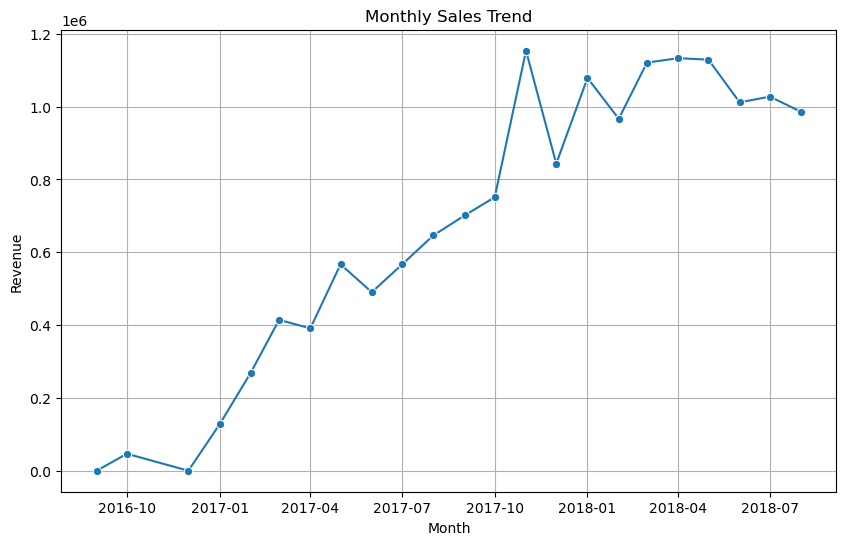

In [36]:
monthly_revenue = monthly_revenue.reset_index()
if monthly_revenue["order_month"].dtype != "<M8[ns]":
    monthly_revenue["order_month"] = monthly_revenue["order_month"].dt.to_timestamp()
    
# Plot sales trend
plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_revenue, x="order_month", y="total_order_value", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

## Bar charts (category performance)

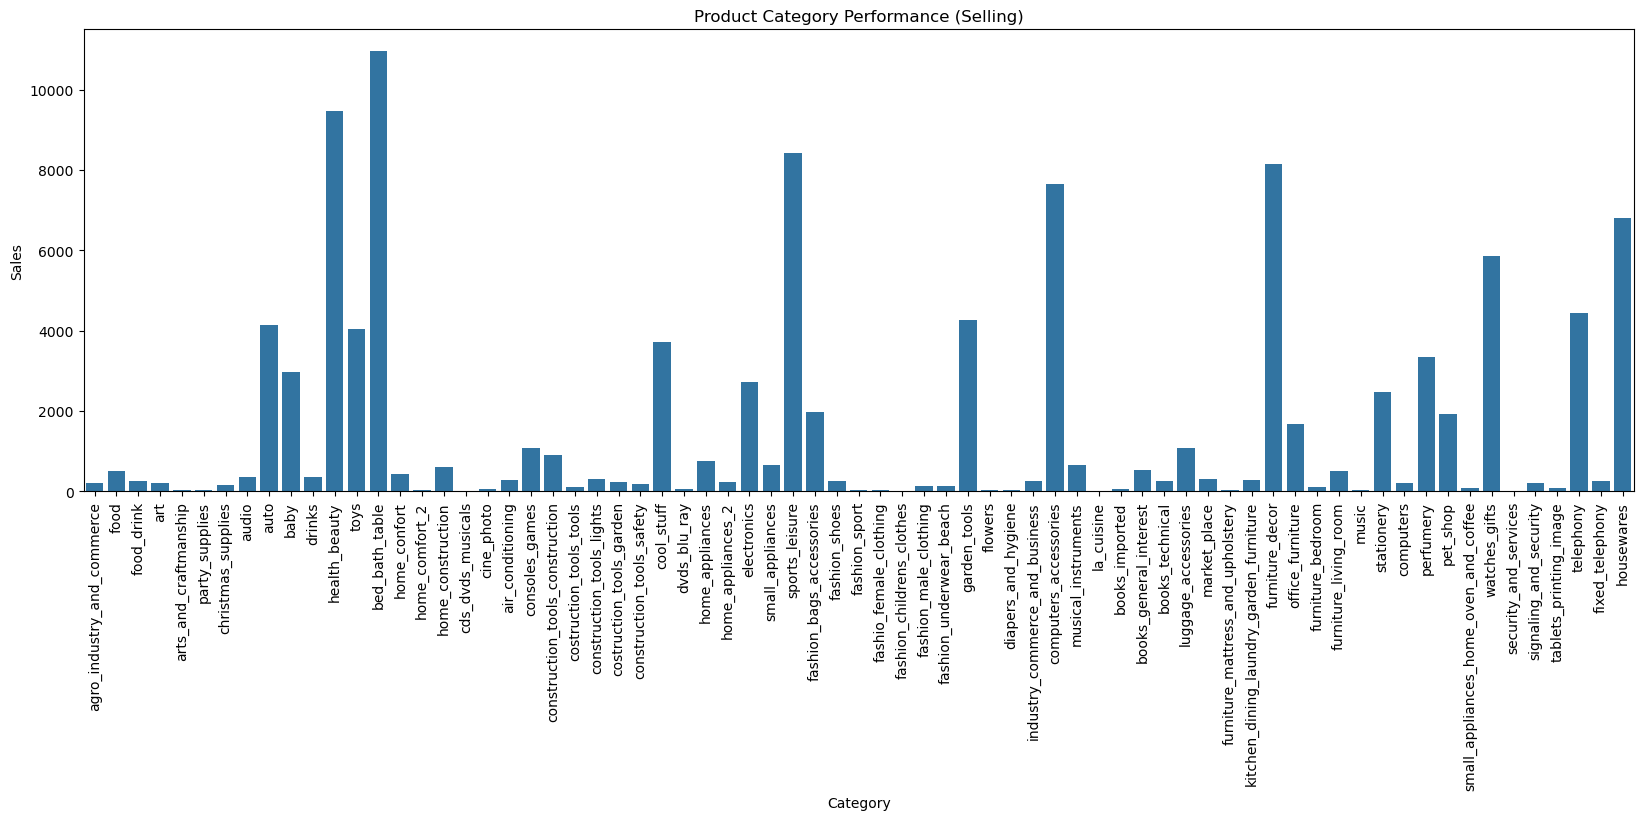

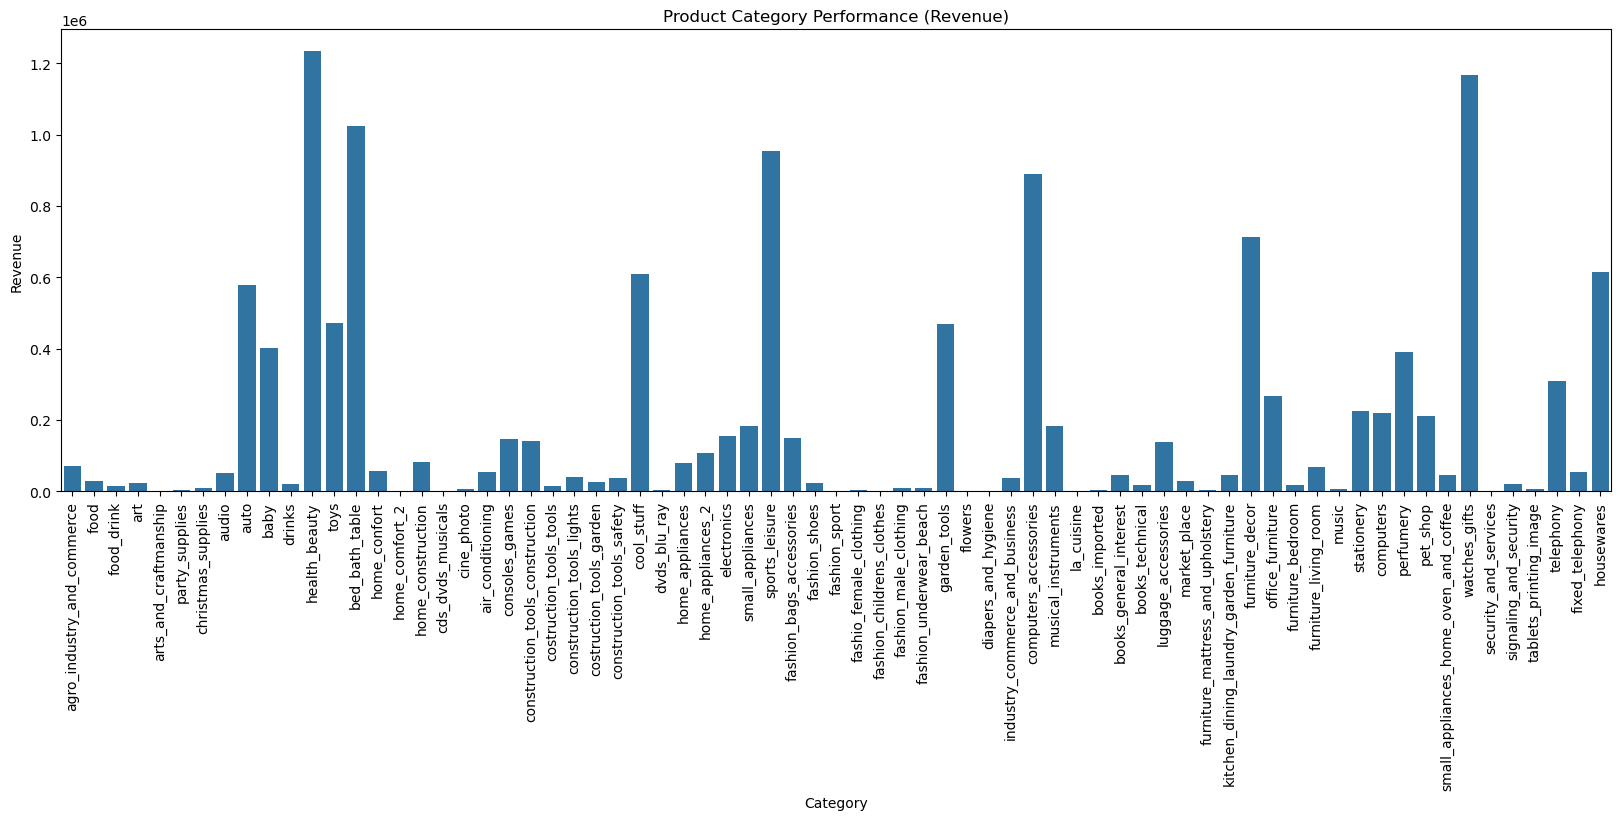

In [37]:
# top_selling_product_categories = top_selling_product_categories.reset_index(name="units_sold")
plt.figure(figsize=(20,6))
sns.barplot(y = "units_sold", x = "product_category_name_english", data = top_selling_product_categories)
plt.title("Product Category Performance (Selling)")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(20,6))
sns.barplot(y = "revenue", x = "product_category_name_english", data = revenue_by_cat)
plt.title("Product Category Performance (Revenue)")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

## Histograms (distribution analysis) 

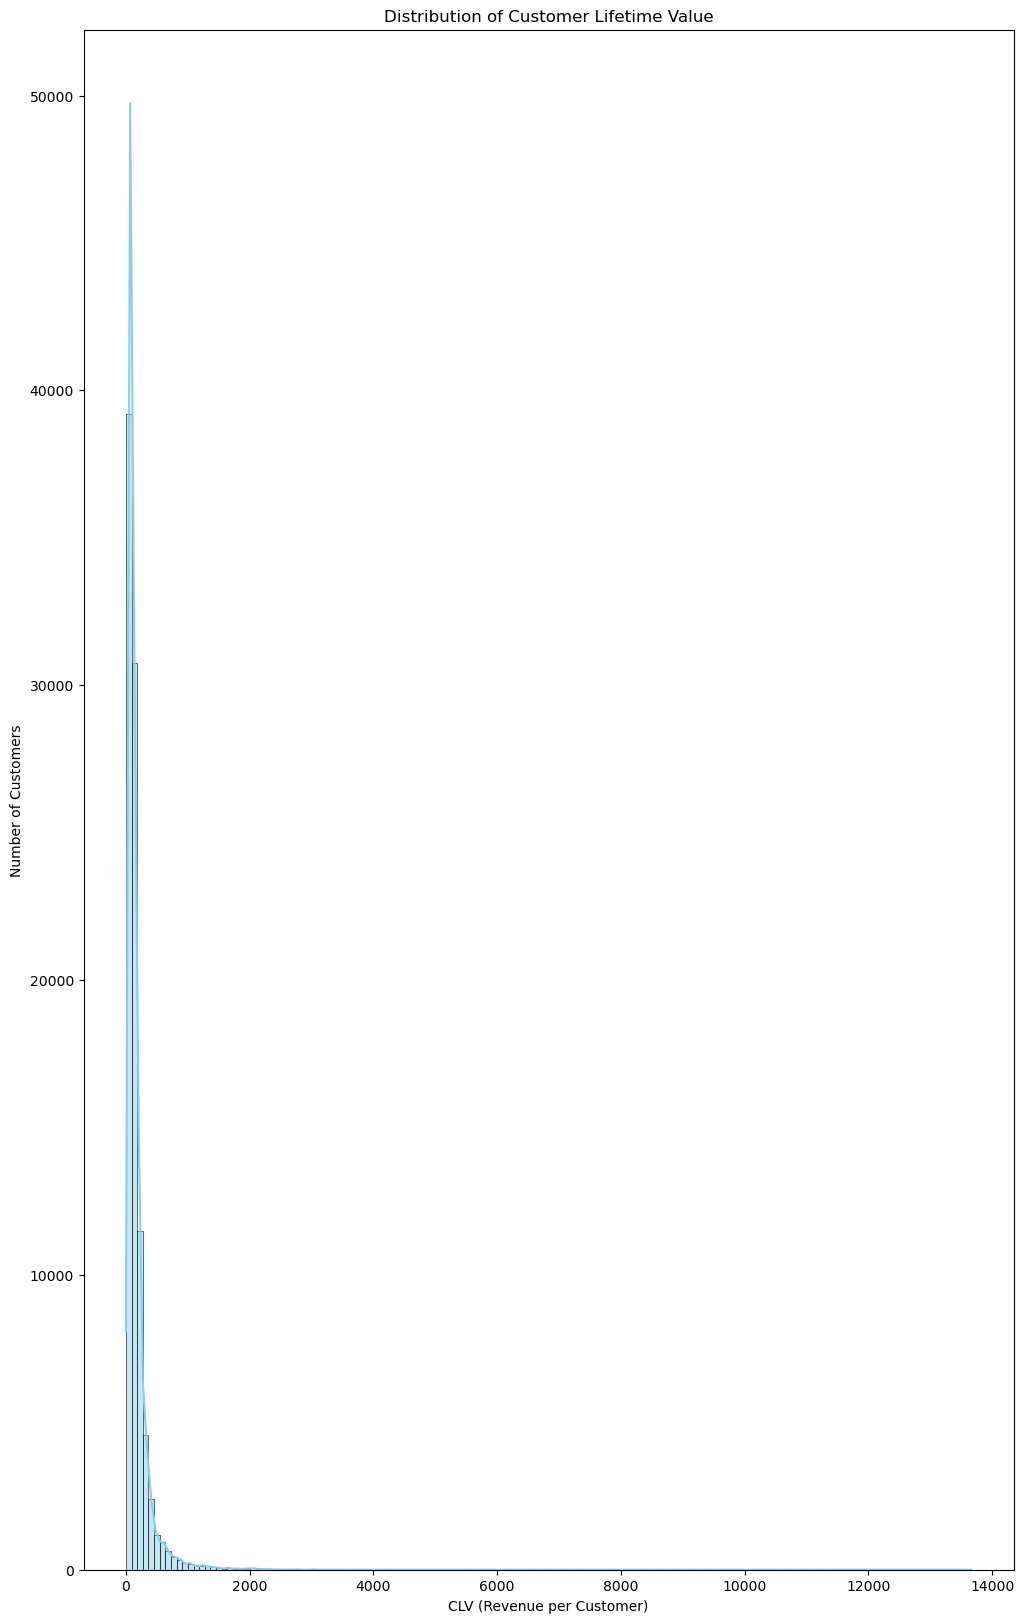

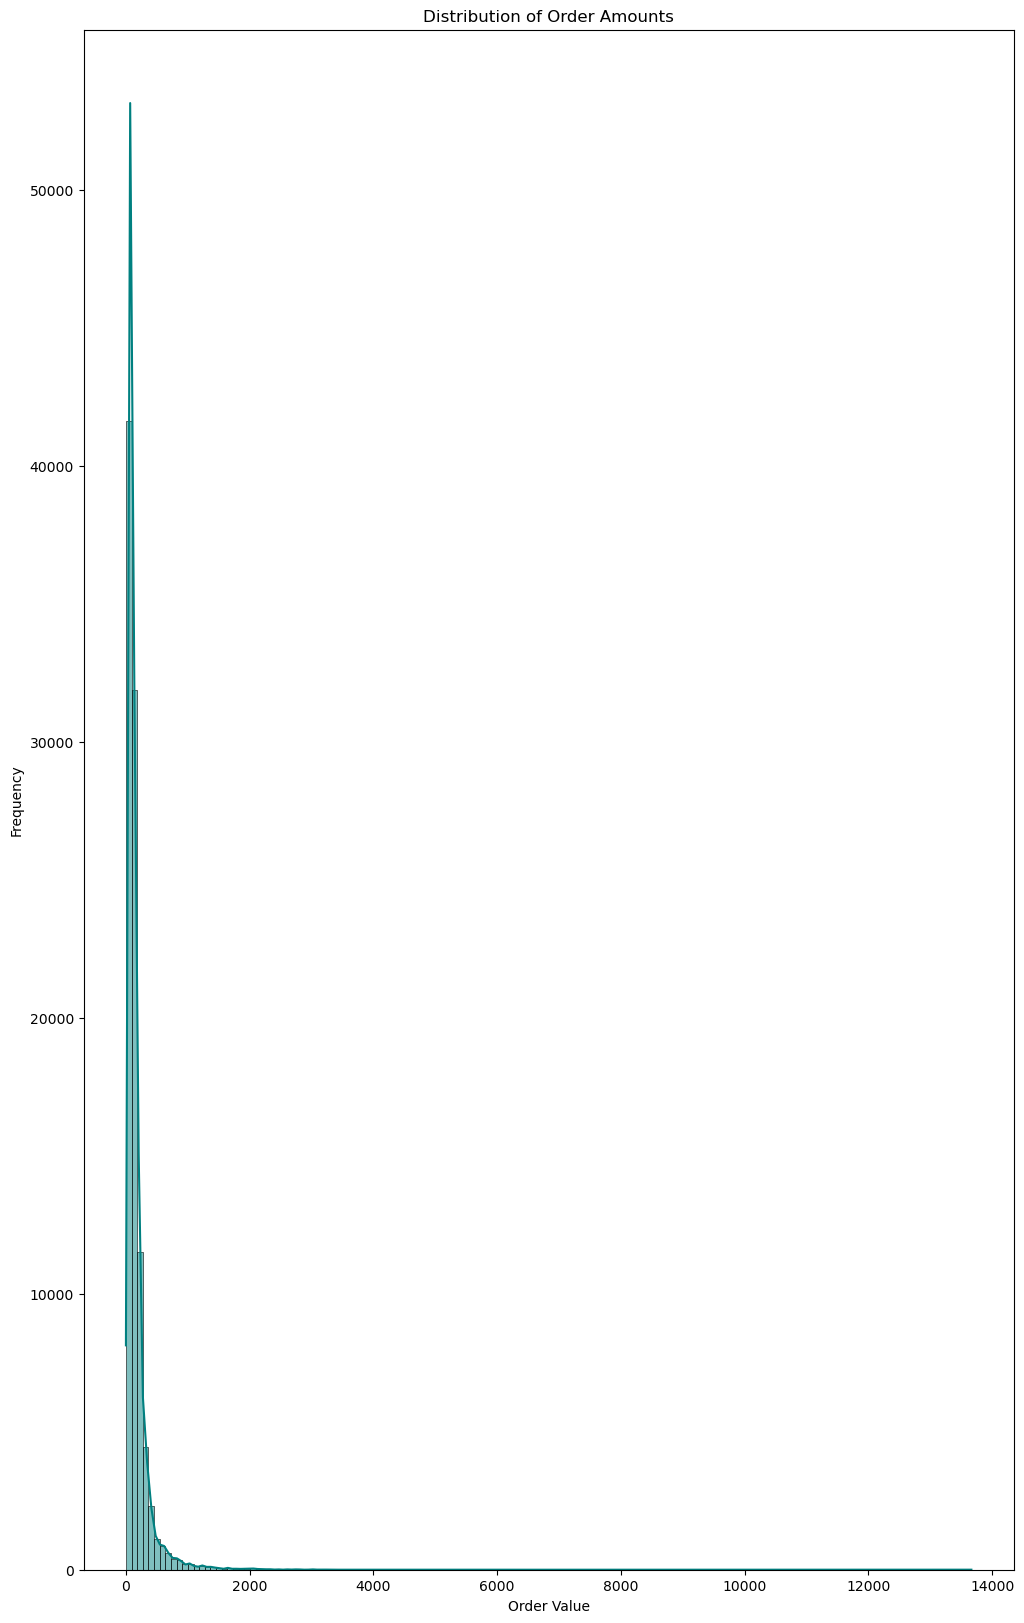

In [38]:
# Histogram of order amounts
# value_of_customers = result[["customer_unique_id", "customer_lifetime_value"]].drop_duplicates()
plt.figure(figsize=(12,20))
sns.histplot(value_of_customers["customer_lifetime_value"], bins=150, kde=True, color="skyblue")
plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("CLV (Revenue per Customer)")
plt.ylabel("Number of Customers")
plt.show()

plt.figure(figsize=(12,20))
sns.histplot(order_analysis["total_order_value"], bins=150, kde=True, color="teal")
plt.title("Distribution of Order Amounts")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()



## Box plots (outlier detection) 

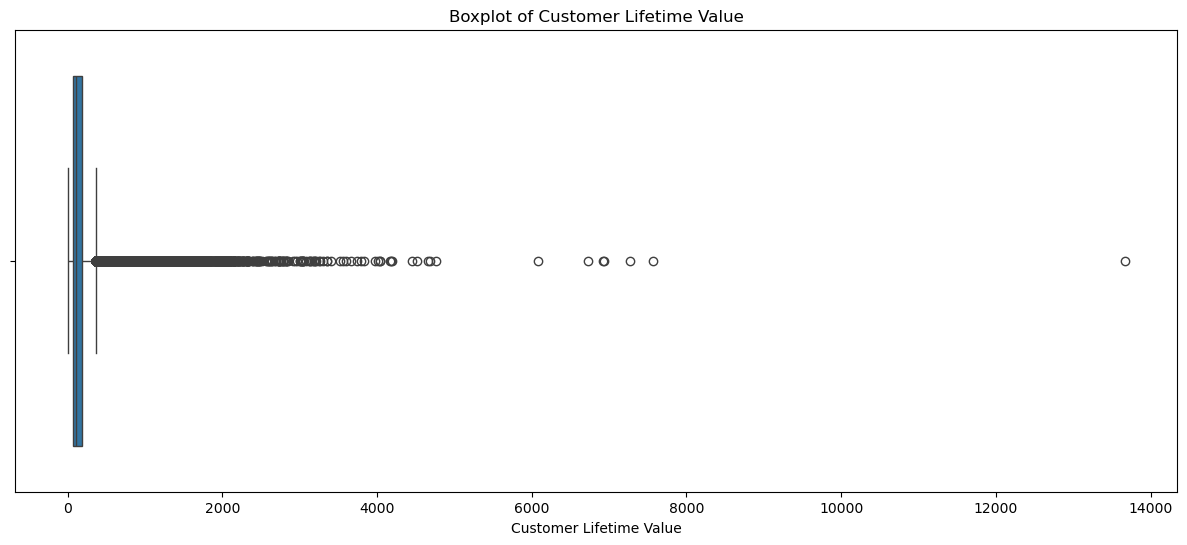

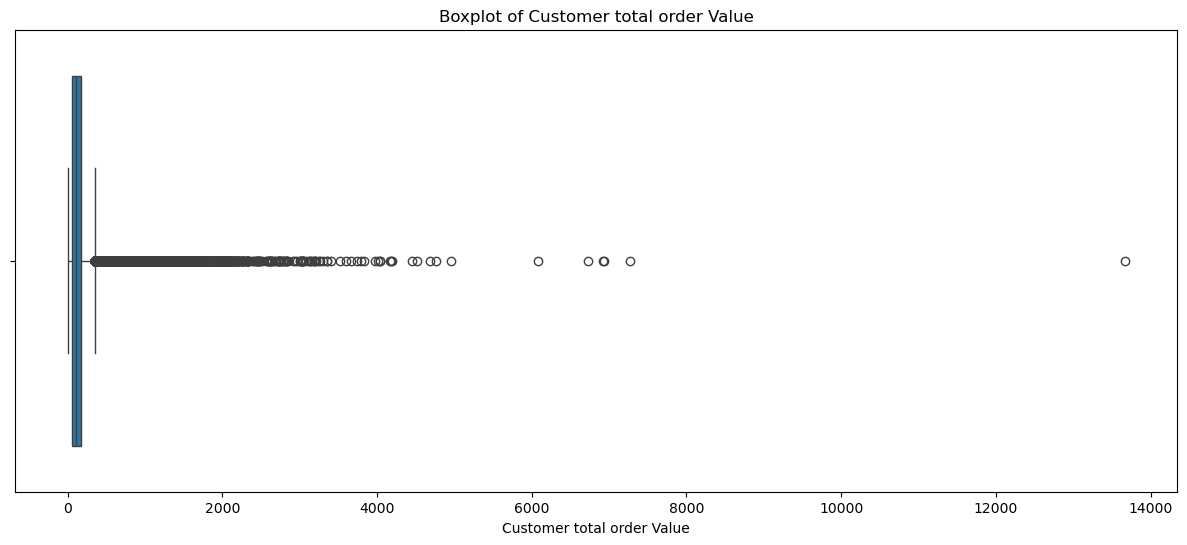

In [39]:
plt.figure(figsize=(15,6))
sns.boxplot(x=value_of_customers["customer_lifetime_value"])
plt.title("Boxplot of Customer Lifetime Value")
plt.xlabel("Customer Lifetime Value")
plt.show()


plt.figure(figsize=(15,6))
sns.boxplot(x=order_analysis["total_order_value"])
plt.title("Boxplot of Customer total order Value")
plt.xlabel("Customer total order Value")
plt.show()

## Heatmaps (correlation analysis) 

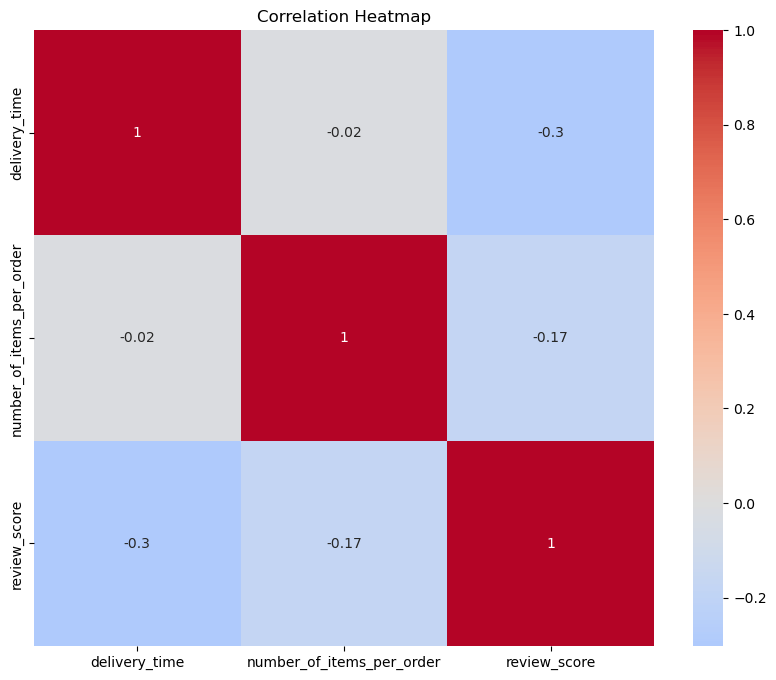

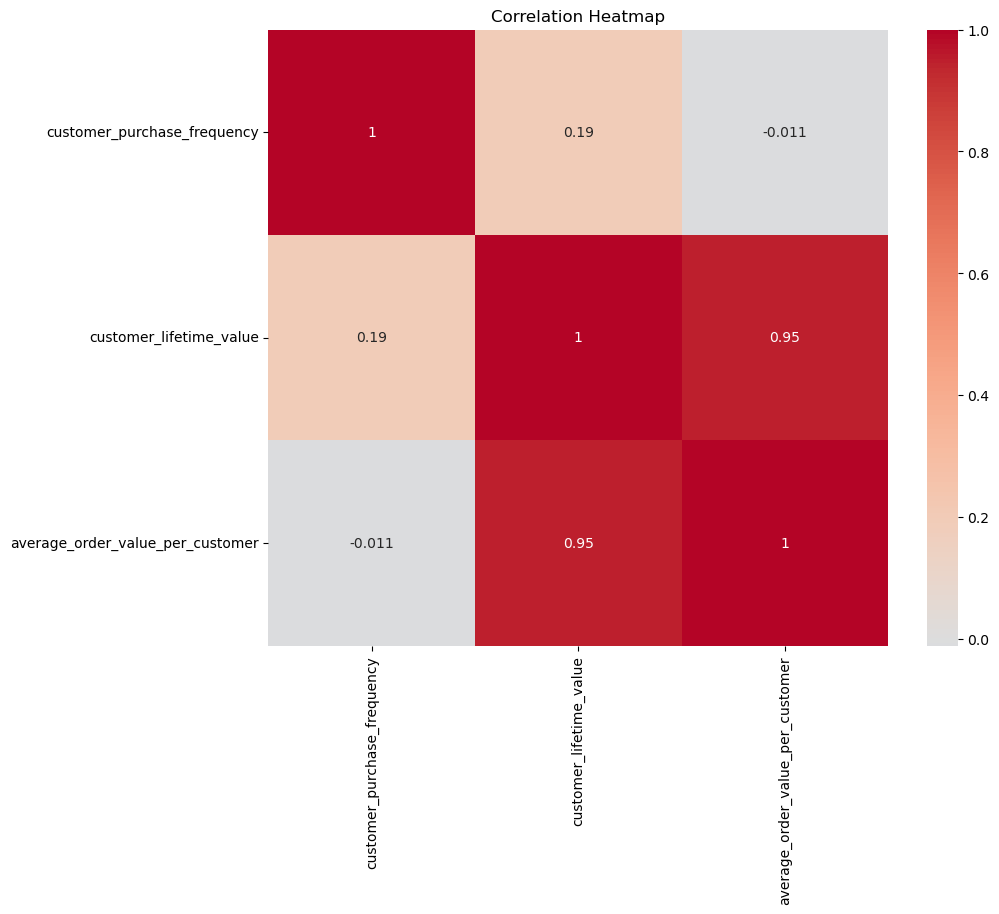

In [40]:
# Compute correlation matrix
corr = result[["delivery_time", "number_of_items_per_order", "review_score"]].corr()
# corr = results[["customer_unique_id", "delivery_time", "number_of_items_per_order", "customer_purchase_frequency", "customer_lifetime_value", "average_order_value_per_customer"]].corr()
# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

corr = result[["customer_purchase_frequency", "customer_lifetime_value", "average_order_value_per_customer"]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Step 7: Business Insights and Recommendations
You must derive clear and actionable insights:
* Identify top revenue-driving factors 
* Highlight customer behavior patterns 
* Evaluate operational inefficiencies 
* Provide strategic recommendations 
Insights must be supported by data and visual evidence.


## Top revenue driving factors

In [41]:
top_10_revenue_derive_product_category = revenue_by_cat.sort_values(ascending=False, by="contribution_pct").head(10)
display(top_10_revenue_derive_product_category)
print(f"Above are the top ten products contribute { top_10_revenue_derive_product_category["contribution_pct"].sum() } % of revenue out of total {len(revenue_by_cat)} categories.")
print("We should ensure adequate inventory of above products.")

,product_category_name,product_category_name_english,revenue,contribution_pct
11,beleza_saude,health_beauty,1233131.72,9.454732
64,relogios_presentes,watches_gifts,1165898.98,8.939241
13,cama_mesa_banho,bed_bath_table,1023300.77,7.845905
32,esporte_lazer,sports_leisure,954604.57,7.319194
44,informatica_acessorios,computers_accessories,888613.62,6.813225
54,moveis_decoracao,furniture_decor,711493.09,5.455197
70,utilidades_domesticas,housewares,615628.69,4.720180
26,cool_stuff,cool_stuff,609964.13,4.676749
8,automotivo,auto,578849.35,4.438184
12,brinquedos,toys,471097.49,3.612023


Above are the top ten products contribute 63.274630034613324 % of revenue out of total 71 categories.
We should ensure adequate inventory of above products.


In [42]:
high_value_customers = value_of_customers.loc[value_of_customers["customer_lifetime_value"] > high_value_customers_spends_threshold]
high_value_customers.sort_values(by="customer_lifetime_value", ascending=False)


,customer_unique_id,customer_lifetime_value
15487,0a0a92112bd4c708ca5fde585afaa872,13664.08
40708,da122df9eeddfedc1dc1f5349a1a690c,7571.63
77318,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
25773,dc4802a71eae9be1dd28f5d788ceb526,6929.31
32994,459bef486812aa25204be022145caa62,6922.21
...,...,...
113353,88a141db4e49b2eaaf35327bcfac9d5f,182.59
104037,4c9af2f58b30f360f0284684405a8255,182.59
22742,adb6b4e82e7e33f5bae129c361cdce17,182.59
94670,fe980244ecb1b2b271cece2e75107fd0,182.56


In [43]:
top_100_sellers = top_sellers.head(100)
display(top_100_sellers)
print(f"Above are the top 100 sellers contribute { top_100_sellers["contribution_pct"].sum() } % of revenue out of total {len(top_sellers)} sellers.")
print("Recommendations is to strengthen partnerships with Top Sellers by providing better commission rates. Ensure they remain loyal and continue driving revenue. Also reduce dependency on them by nurturing mid‑tier sellers.")

,seller_id,revenue,contribution_pct
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1.717212
982,53243585a1d6dc2643021fd1853d8905,217940.44,1.648766
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1.489455
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,1.444329
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,1.411442
...,...,...,...
1867,9f505651f4a6abe901a56cdc21508025,25912.84,0.196036
251,16090f2ca825584b5a147ab24aa30c86,25579.16,0.193512
2137,b94cc9f10ddc85e4ba73a6f7974e7101,25346.10,0.191749
1920,a416b6a846a11724393025641d4edd5e,24930.24,0.188603


Above are the top 100 sellers contribute 45.52465886660484 % of revenue out of total 2970 sellers.
Recommendations is to strengthen partnerships with Top Sellers by providing better commission rates. Ensure they remain loyal and continue driving revenue. Also reduce dependency on them by nurturing mid‑tier sellers.


## Customer behavior patterns 

In [44]:
print("Revenue from new customers =", revenue_from_new_customers)
print("Revenue from repeat customers =", round(revenue_from_repeat_customers,2))

print(f"This means {(revenue_from_new_customers * 100)/(revenue_from_new_customers+revenue_from_repeat_customers)} % of revenue is coming from new customers, while repeat customers contribute only {(revenue_from_repeat_customers * 100)/(revenue_from_new_customers+revenue_from_repeat_customers)} %")

print("This means business is heavily dependent on acquiring new customers. Repeat customers are contributing very little, which is a risk. Recommendations is to Loyalty Reward Programs for repeat purchases with points, discounts, exclusive offers.")

Revenue from new customers = 14554876.59
Revenue from repeat customers = 864057.68
This means 94.39612579657232 % of revenue is coming from new customers, while repeat customers contribute only 5.603874203427679 %
This means business is heavily dependent on acquiring new customers. Repeat customers are contributing very little, which is a risk. Recommendations is to Loyalty Reward Programs for repeat purchases with points, discounts, exclusive offers.


## Evaluate operational inefficiencies 

In [45]:
delivery_analysis = result[["order_id", "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date", "delivery_time"]].drop_duplicates()

delivery_analysis["approval_delays"] = delivery_analysis["order_approved_at"] - delivery_analysis["order_purchase_timestamp"]

delivery_analysis["carrier_delays"] = delivery_analysis["order_delivered_carrier_date"] - delivery_analysis["order_approved_at"]

delivery_analysis["carrier_delivery_delays"] = delivery_analysis["order_delivered_customer_date"] - delivery_analysis["order_delivered_carrier_date"]

display(delivery_analysis.describe())

print("Long transit times (avg. 12 ays) may cause dissatisfaction, lower repeat purchases, and negative reviews. Recommendations is to Optimize carrier contracts: Negotiate faster pickup and shipping SLAs.")

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_delays,carrier_delays,carrier_delivery_delays
count,96455,96455,96455,96455,96455,96455,96455,96455,96455
mean,2018-01-02 00:26:23.673806336,2018-01-02 10:43:03.401710592,2018-01-05 05:53:41.200134656,2018-01-14 13:49:28.328526336,2018-01-25 18:04:03.421284864,12 days 13:23:04.654719817,0 days 10:16:39.727904204,2 days 19:10:37.798424135,9 days 07:55:47.128391477
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0 days 12:48:07,0 days 00:00:00,-172 days +18:44:38,-17 days +21:41:31
25%,2017-09-14 09:39:02.500000,2017-09-14 14:42:23,2017-09-18 17:06:18.500000,2017-09-25 22:56:47,2017-10-05 00:00:00,6 days 18:22:19,0 days 00:12:55,0 days 20:58:51.500000,4 days 02:23:31.500000
50%,2018-01-20 20:00:12,2018-01-22 13:49:24,2018-01-24 16:28:58,2018-02-02 19:52:30,2018-02-16 00:00:00,10 days 05:11:22,0 days 00:20:36,1 days 19:34:46,7 days 02:23:34
75%,2018-05-05 18:53:33,2018-05-06 10:52:57.500000,2018-05-08 14:34:30,2018-05-15 23:09:15.500000,2018-05-28 00:00:00,15 days 17:17:00.500000,0 days 14:31:02.500000,3 days 13:47:54,12 days 00:41:55.500000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,209 days 15:05:12,30 days 21:26:37,125 days 18:18:06,205 days 04:35:00
std,NaN,NaN,NaN,NaN,NaN,9 days 13:06:12.842960863,0 days 20:32:10.134771828,3 days 12:53:31.746860544,8 days 18:15:07.511611066


Long transit times (avg. 12 ays) may cause dissatisfaction, lower repeat purchases, and negative reviews. Recommendations is to Optimize carrier contracts: Negotiate faster pickup and shipping SLAs.


## Provide strategic recommendations 

In [46]:
print("Already provided with analysis.")

Already provided with analysis.
